<a href="https://colab.research.google.com/github/AuliaRestyy/machineLearning/blob/main/QUIZ_244107020015_Aulia_Resty_Azizah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

In this Quiz #1 you need to perform exploratory data analysis (EDA) and preprocessing using "Census Income" dataset. The dataset is tabular data which has several missing value in some variables. Moreover, you may need to adjust the name of variables (if needed).

To guide you through this task, some code has beed provided including, download the data, loading the data, and metadata inspection.

# Load Data and Inspect Metadata

In [2]:
# Install UCI REPO Library
!pip install -q ucimlrepo

In [3]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [4]:
# fetch data
adult_income = fetch_ucirepo(id=2)

In [5]:
# Data
X = adult_income.data.features
y = adult_income.data.targets

# Concate Features and Target
df = pd.concat([X, y], axis=1)

# Show Top 5
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [6]:
# Data Size
df.shape

(48842, 15)

In [7]:
# Inspect metadata
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

# Part 1 - Data Loading dan Data Imputation

## Task 1 (5 points)
1.   Do inspection to get the information about dataset
2.   **Which variable(s)** has **missing values**? **How many is it**?

In [ ]:
df.info()
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

'''
Census income dataset contains 48.842 rows and 16 columns with 6 numeric variables (int64) and 9 categorical variables (str).
There are 3 variables that has missing values which is workclass, occupation, and native-country.
'''

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       48842 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      48842 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  48842 non-null  str  
 14  income          48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


'\nCensus income dataset contains 48.842 rows and 16 columns with 6 numeric variables (int64) and 9 categorical variables (str).\nThere are 3 variables that has missing values which is workclass, occupation, and native-country.\n'

## Task 2 (5 points)
1. Perform data imputation on missing values.
2. Verified the missing values for each variable. Is it still there?

Missing values were imputed using the mode of each variable because the variables are categorical. When i checked again, the missing values were not there.

In [ ]:
for column in ['workclass', 'occupation', 'native-country']:
    df[column] = df[column].fillna(df[column].mode()[0])

missing_values_after = df.isnull().sum()
missing_values_after[missing_values_after > 0]

Series([], dtype: int64)

## Task 3 (10 points)
Do inspection to all the quantitative variables (features). If you found an **inappropriate value(s)**, replace it with '**Others**'. Also, if you found any typos value(s), **fix the typos**.

In [ ]:
categorical_columns = df.select_dtypes(include=['object', 'int64', 'str']).columns

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


age:
[39 50 38 53 28 37 49 52 31 42 30 23 32 40 34 25 43 54 35 59 56 19 20 45
 22 48 21 24 57 44 41 29 18 47 46 36 79 27 67 33 76 17 55 61 70 64 71 68
 66 51 58 26 60 90 75 65 77 62 63 80 72 74 69 73 81 78 88 82 83 84 85 86
 87 89]

workclass:
<StringArray>
[       'State-gov', 'Self-emp-not-inc',          'Private',
      'Federal-gov',        'Local-gov',                '?',
     'Self-emp-inc',      'Without-pay',     'Never-worked']
Length: 9, dtype: str

fnlwgt:
[ 77516  83311 215646 ... 173449  89686 350977]

education:
<StringArray>
[   'Bachelors',      'HS-grad',         '11th',      'Masters',
          '9th', 'Some-college',   'Assoc-acdm',    'Assoc-voc',
      '7th-8th',    'Doctorate',  'Prof-school',      '5th-6th',
         '10th',      '1st-4th',    'Preschool',         '12th']
Length: 16, dtype: str

education-num:
[13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8]

marital-status:
<StringArray>
[        'Never-married',    'Married-civ-spouse',              'Divorced

In [ ]:
df['workclass'] = df['workclass'].replace('?', 'Others')
df['occupation'] = df['occupation'].replace('?', 'Others')
df['native-country'] = df['native-country'].replace('?', 'Others')

df['native-country'] = df['native-country'].replace(
    'Trinadad&Tobago', 'Trinidad&Tobago'
)

df['income'] = df['income'].replace({
    '<=50K.': '<=50K',
    '>50K.': '>50K'
})

In [ ]:
for column in ['workclass', 'occupation', 'native-country', 'income']:
    print(f"\n{column}:")
    print(df[column].unique())

'''
The '?' values in workclass, occupation, and native-country were replaced with 'Others'.
The typo 'Trinadad&Tobago' in native-country corrected to 'Trinidad&Tobago'.
The inconsistent valuese in income were corrected by removing the period.
'''

# The native-country column has a value 'South', which is not a real country.
# It could be an incomplete value or a typo, but there is no strong proof to change it.
# So this value was left as is.


workclass:
<StringArray>
[       'State-gov', 'Self-emp-not-inc',          'Private',
      'Federal-gov',        'Local-gov',           'Others',
     'Self-emp-inc',      'Without-pay',     'Never-worked']
Length: 9, dtype: str

occupation:
<StringArray>
[     'Adm-clerical',   'Exec-managerial', 'Handlers-cleaners',
    'Prof-specialty',     'Other-service',             'Sales',
      'Craft-repair',  'Transport-moving',   'Farming-fishing',
 'Machine-op-inspct',      'Tech-support',            'Others',
   'Protective-serv',      'Armed-Forces',   'Priv-house-serv']
Length: 15, dtype: str

native-country:
<StringArray>
[             'United-States',                       'Cuba',
                    'Jamaica',                      'India',
                     'Others',                     'Mexico',
                      'South',                'Puerto-Rico',
                   'Honduras',                    'England',
                     'Canada',                    'Germany',
  

"\nThe '?' values in workclass, occupation, and native-country were replaced with 'Others'. \nThe typo 'Trinadad&Tobago' in native-country corrected to 'Trinidad&Tobago'. \nThe inconsistent valuese in income were corrected by removing the period.\n"

# Part 2 - Visual Inspection



## Task 1 - Data Visualization (20 points)
Do inspection on this following variabels,
1. On the 'age' by using a histogram
2. On the 'education' using a barchart
3. On the 'income' to 'hours_per_week' by using a boxplot (grouped by income)
4. On the 'age' to 'capital-gain' and 'capital-loss' using lineplot (lineplot with multiple x-data)

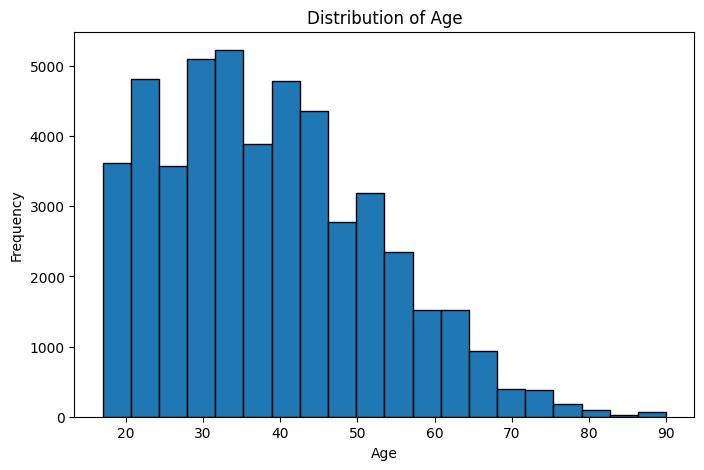

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df['age'], bins=20, edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')
plt.show()

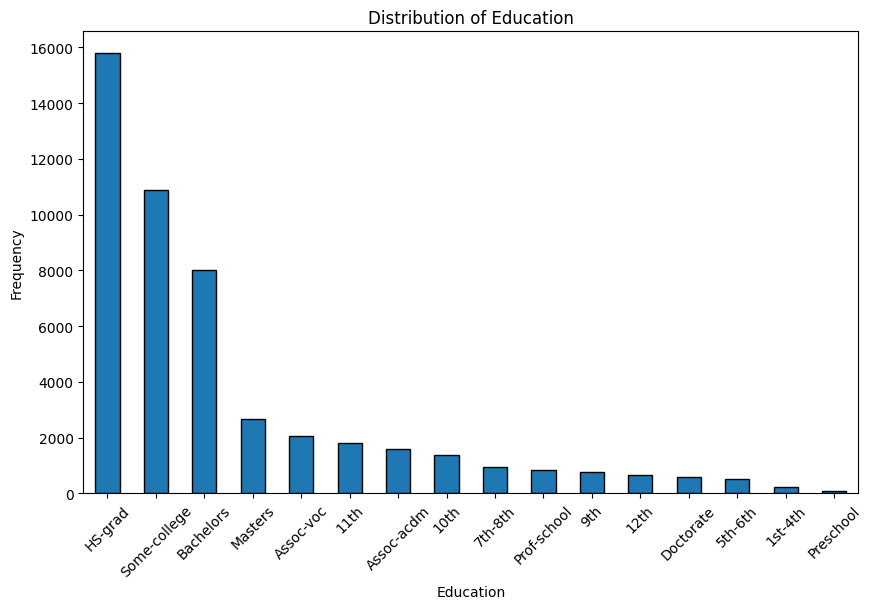

In [ ]:
plt.figure(figsize=(10, 6))
df['education'].value_counts().plot(kind='bar', edgecolor='black')

plt.xlabel('Education')
plt.ylabel('Frequency')
plt.title('Distribution of Education')
plt.xticks(rotation=45)
plt.show()

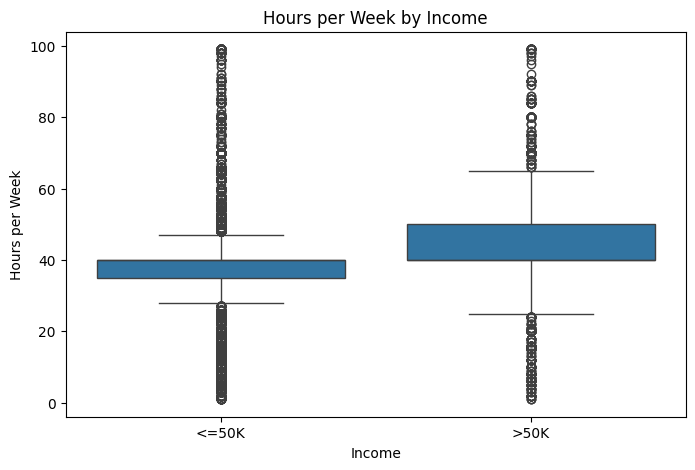

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='income', y='hours-per-week')

plt.xlabel('Income')
plt.ylabel('Hours per Week')
plt.title('Hours per Week by Income')
plt.show()

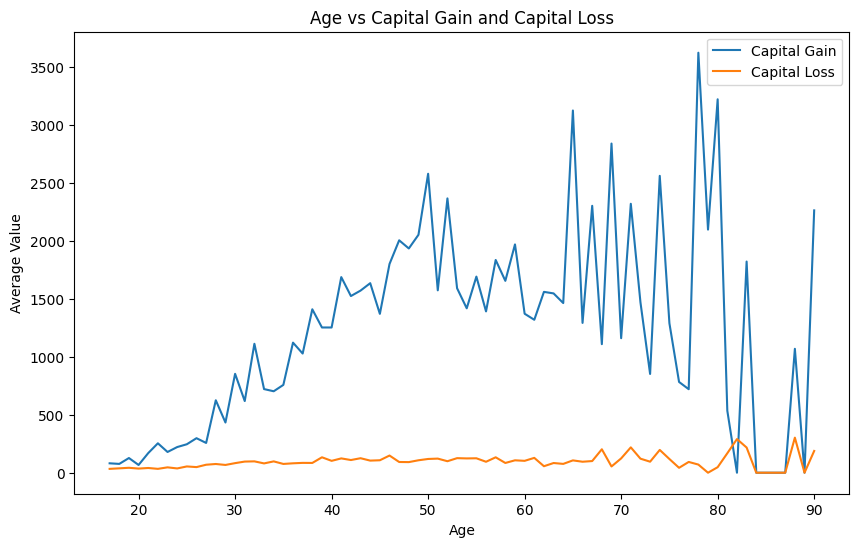

In [ ]:
age_data = df.groupby('age')[['capital-gain', 'capital-loss']].mean().reset_index()

plt.figure(figsize=(10, 6))

plt.plot(age_data['age'], age_data['capital-gain'], label='Capital Gain')
plt.plot(age_data['age'], age_data['capital-loss'], label='Capital Loss')

plt.xlabel('Age')
plt.ylabel('Average Value')
plt.title('Age vs Capital Gain and Capital Loss')
plt.legend()
plt.show()

## Task 2 - Visual Analysis (15 points)
1. What kind of distribution showed in 'age'?
2. If you find missing values in 'age', what kind of data impute method will you use? Why?
3. How many outliner for each category (group) in 'income' related to 'hour-per-week'? Which category has more outlier?

In [ ]:
'''
1. Right-skewed because the age is in the range of 17 to 90, with majority of the age froup is 25 to 45 (productive age).
2. If i find misisng values in 'age' i will replace them with median imputation because age is a numerical variable with a right skewed distribution.
3. <=50K has 11,706 outliers and >50K has 781 outliers. The <=50k category has more outliers than the >50k category.
'''

# 3

for income_category in df['income'].unique():
    data = df[df['income'] == income_category]['hours-per-week']

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data < lower_bound) | (data > upper_bound)]

    print(f"Income: {income_category}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Lower Bound: {lower_bound}")
    print(f"Upper Bound: {upper_bound}")
    print(f"Number of outliers: {len(outliers)}")
    print()

Income: <=50K
Q1: 35.0
Q3: 40.0
IQR: 5.0
Lower Bound: 27.5
Upper Bound: 47.5
Number of outliers: 11706

Income: >50K
Q1: 40.0
Q3: 50.0
IQR: 10.0
Lower Bound: 25.0
Upper Bound: 65.0
Number of outliers: 781



# Part 3 - Encoding in Categorical Variable

## Task 1 (5 points)
Do encoding process on 'Sex' and 'Income', while 'Income' is target variable.

In [8]:
df['sex'] = df['sex'].map({
    'Female': 0,
    'Male': 1
})

df['income'] = df['income'].map({
    '<=50K': 0,
    '>50K': 1
})

df[['sex', 'income']].head()

,sex,income
0,1,0.0
1,1,0.0
2,1,0.0
3,1,0.0
4,0,0.0


# Part 4 - Correlation Analysis

## Task 1 (10 points)
1. Do correlation analysis on the following variabels: 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', and 'income' (encoded version from previous task)
2. Based on the result, what kind of information you get?

In [9]:
correlation_data = df[
    ['age', 'education-num', 'hours-per-week',
     'capital-gain', 'capital-loss', 'income']
]

correlation_matrix = correlation_data.corr()
correlation_matrix

,age,education-num,hours-per-week,capital-gain,capital-loss,income
age,1.000000,0.030940,0.071558,0.077229,0.056944,0.234037
education-num,0.030940,1.000000,0.143689,0.125146,0.080972,0.335154
hours-per-week,0.071558,0.143689,1.000000,0.082157,0.054467,0.229689
capital-gain,0.077229,0.125146,0.082157,1.000000,-0.031441,0.223329
capital-loss,0.056944,0.080972,0.054467,-0.031441,1.000000,0.150526
income,0.234037,0.335154,0.229689,0.223329,0.150526,1.000000


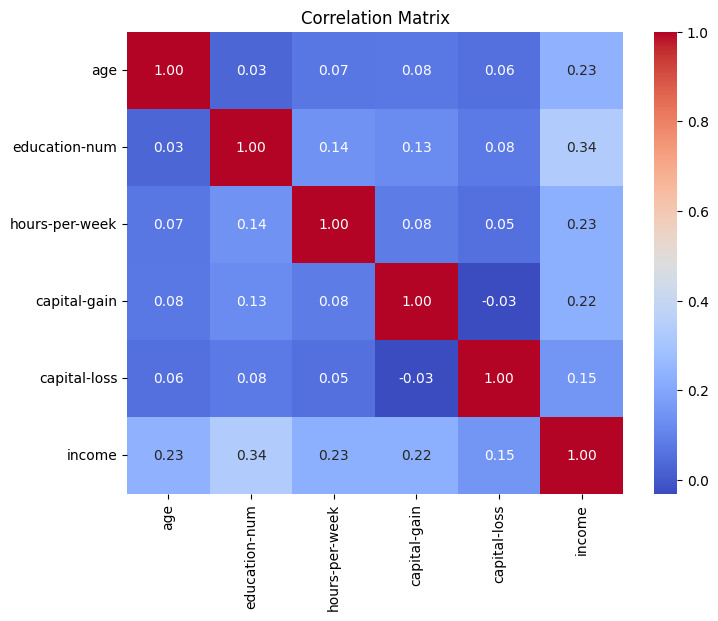

In [10]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

# The strongest correlation with income is education-num (0.335),
# followed by age (0.234037), hours-per-week (0.229689), capital-gain (0.223329), and capital-loss (0.150526)
# All variables have positive but weak correlation with income,
# so no single variable can predict income alone.
# The features also have very low correlation with each other (no multicollinearity),

# Part 5 - Preprocessing on MNIST Dataset

In this part, you need to perform EDA and simple preprocessing on MNIST dataset. This dataset contain images of handwritten digit from 0 to 9. A pre configuration is provided to help you to load the data and inspect some images.

Hints:
1. You only need to use the **Test** set.
2. You need to perform to all of images in test set (10k images). You may need a function to complete this task (optional).

In [11]:
# Fetch data and inspect data shape
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load train & test split
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


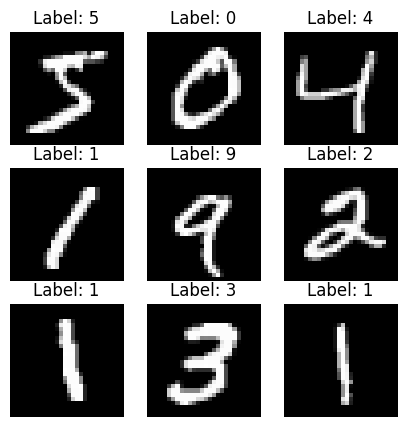

In [12]:
# Visual Inspection
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

## Task 1 (10 points)
1. Perform **upsampling** on the images to 32x32
2. Show the 5 sample of the result.


Hint: You need to store the result in an empty array. Replacing data to the  **X_test** cannot be done due to the shape of the array (10000, (28,28)). You need to create an array which match with the size of the new images.

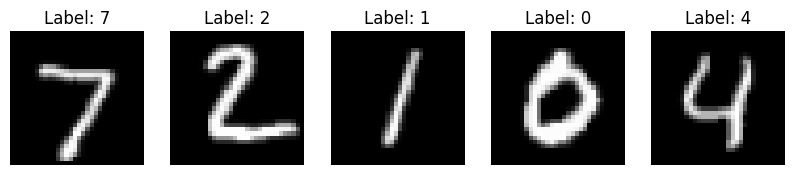

Original shape: (10000, 28, 28)
Resized shape: (10000, 32, 32)


In [13]:
from tensorflow.image import resize

X_test_resized = np.empty((X_test.shape[0], 32, 32), dtype=np.float32)

for i in range(X_test.shape[0]):
    X_test_resized[i] = resize(
        X_test[i][..., np.newaxis],
        (32, 32)
    ).numpy().squeeze()

plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test_resized[i], cmap='gray')
    plt.title(f'Label: {y_test[i]}')
    plt.axis('off')

plt.show()

print("Original shape:", X_test.shape)
print("Resized shape:", X_test_resized.shape)

## Task 2 (10 points)
Perform normalization, so the pixel value will have a value in range of 0 until 1

In [14]:
X_test_normalized = X_test_resized / 255.0

print("Shape:", X_test_normalized.shape)
print("Minimum pixel value:", X_test_normalized.min())
print("Maximum pixel value:", X_test_normalized.max())

Shape: (10000, 32, 32)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


## Task 3 (10 points)
Transform / reshape the images into 1 dimensional array. Do it to the all images (after resizing and normalization).

Hint: You may need an empty array to store the result

In [15]:
X_test_reshaped = np.empty((X_test_normalized.shape[0], 32 * 32))

for i in range(X_test_normalized.shape[0]):
    X_test_reshaped[i] = X_test_normalized[i].reshape(-1)

print("Shape after reshaping:", X_test_reshaped.shape)

Shape after reshaping: (10000, 1024)
